# Polynomial Regression — Pipeline Section

This notebook is a focused extract of the **Pipeline** portion of the original *Polynomial Regression Implementation* notebook — the setup cells it depends on (imports, synthetic dataset, train/test split) plus the pipeline-building and comparison cells. All code is copied unchanged from the original.


## 1. Importing Required Libraries

Loads pandas, numpy, and matplotlib — the basic tools needed to generate data and plot results.


In [ ]:
## Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Generating a Synthetic Non-Linear Dataset

Creates a curved (quadratic) dataset with noise: \( y = 0.5X^2 + 1.5X + 2 + \text{noise} \). This is the data the pipeline will be fit on later.


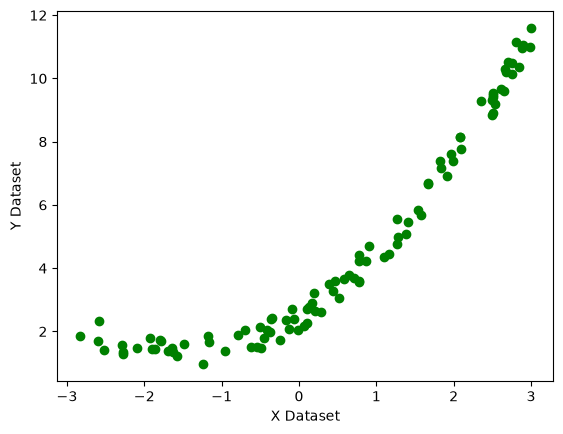

In [2]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.rand(100, 1)

plt.scatter(X, y, color='g')
plt.xlabel('X Dataset')
plt.ylabel('Y Dataset')

plt.show()

## 3. Train-Test Split

Splits the data into training (80%) and testing (20%) sets, used consistently throughout the pipeline section.


In [3]:
## Train Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Importing Linear Regression

This cell (kept from the original notebook) imports `LinearRegression` from scikit-learn — the regression algorithm the pipeline will use internally.


In [4]:
## Implement Simple Linear Regression

from sklearn.linear_model import LinearRegression

regression_1 = LinearRegression()

## 5. Importing Polynomial Feature Transformation

Imports `PolynomialFeatures` — the tool the pipeline uses to expand `X` into polynomial terms (\(X, X^2, X^3, \dots\)) before fitting the linear model.


In [5]:
## Apply Polynomial Transformation  (Increases Degree of equations)

from sklearn.preprocessing import PolynomialFeatures

## 6. Introducing Pipelines

A **Pipeline** chains multiple steps — here, "transform features into polynomial terms" followed by "fit a linear regression" — into a single object. Instead of manually transforming data and then fitting a model as two separate steps, the pipeline does both in one call, which keeps the code clean and makes it easy to swap in different polynomial degrees.


# Pipeline Concepts

## 7. Importing the Pipeline Tool

Imports `Pipeline` from `sklearn.pipeline`.


In [6]:
from sklearn.pipeline import Pipeline

## 8. Defining a Reusable Polynomial Regression Pipeline Function

`poly_regression(degree)` builds a pipeline of `PolynomialFeatures(degree)` → `LinearRegression`, fits it on the training data, predicts across a smooth range of `X` values, and plots:
- the fitted curve (red),
- training points (blue),
- test points (green).

**Why it's used:** It packages the "transform + fit + predict + plot" workflow into one reusable function, so different polynomial degrees can be compared side by side just by changing one argument.

**Formula (general degree-`d` polynomial model):**
$$
y = \beta_0 + \beta_1 X + \beta_2 X^2 + \dots + \beta_d X^d
$$


In [7]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_features = PolynomialFeatures(
        degree=degree,
        include_bias=True
    )
 
    lin_reg = LinearRegression()

    poly_regression = Pipeline([
        ("poly_features", poly_features),
        ("lin_reg", lin_reg)
    ])

    poly_regression.fit(X_train, y_train)  ## polynomial and fit of linear regression
    y_pred_new = poly_regression.predict(X_new)

    # Plotting prediction line
    plt.plot(
        X_new,
        y_pred_new,
        'r',
        label="Degree " + str(degree),
        linewidth=3
    )

    plt.plot(
        X_train,
        y_train,
        ".b",
        linewidth=3
    )

    plt.plot(
        X_test,
        y_test,
        "g.",
        linewidth=3
    )

    plt.legend(loc="upper left")

    plt.xlabel("X")
    plt.ylabel("y")
    
    plt.axis([-4, 4, 0, 10])
    plt.show()

## 9. Degree 1 — Straight Line

Runs the pipeline with `degree=1`, equivalent to plain linear regression — a straight-line fit.


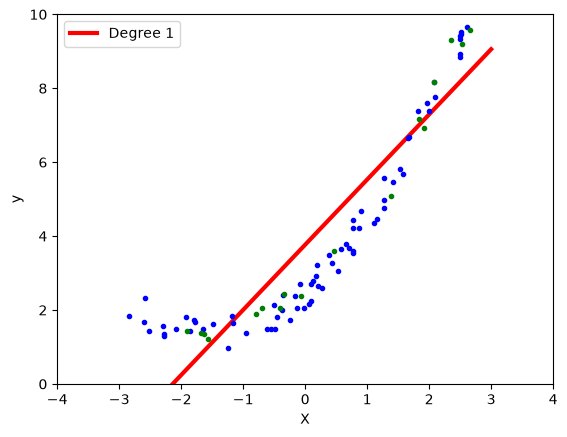

In [8]:
poly_regression(1)     ## Degree 1

## 10. Degree 2 — Quadratic Fit

Runs the pipeline with `degree=2`, matching the true quadratic shape of the underlying data.


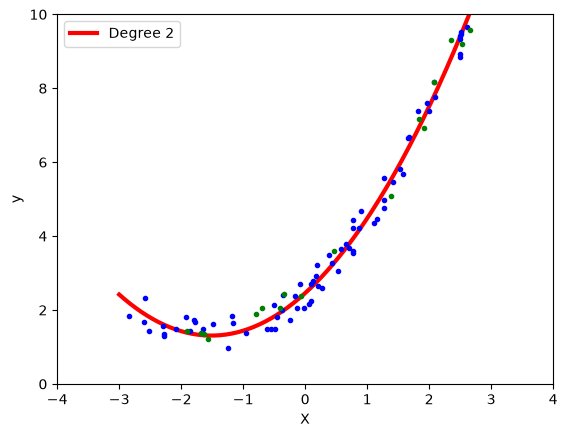

In [9]:
poly_regression(2)     ## Degree 2

## 11. Degree 3 — Cubic Fit

Runs the pipeline with `degree=3`, adding one more degree of flexibility.


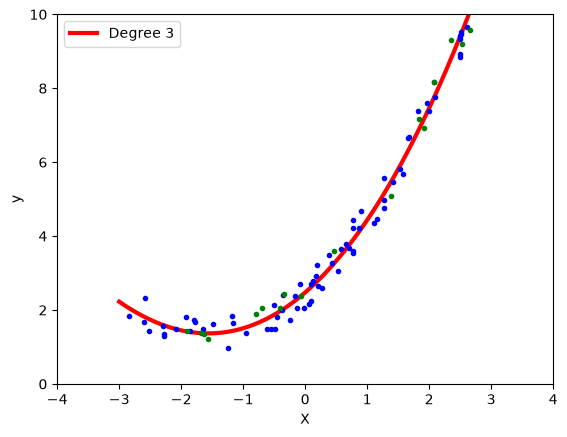

In [10]:
poly_regression(3)     ## Degree 3

## 12. Degree 15 — Overfitting Demonstration

Runs the pipeline with `degree=15`. With this much flexibility, the curve bends to chase individual training points, illustrating **overfitting**: an excellent-looking fit on training data that generalizes poorly — the classic bias-variance tradeoff.


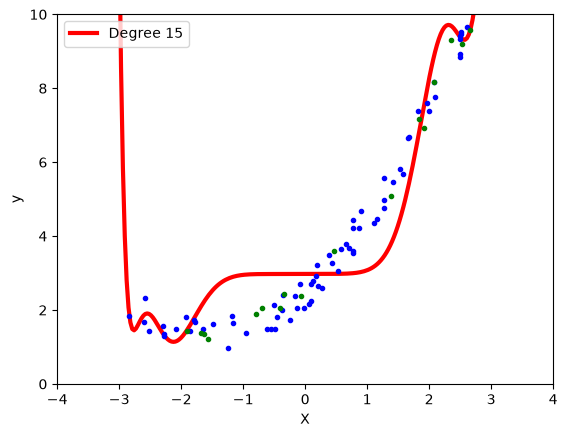

In [11]:
## Overfitting

poly_regression(15)     ## Degree 15